In [2]:
import qsp_rs as qsp
import numpy as np


def poly_1(n_max):
    n_star = (n_max - 3 * np.sqrt(n_max)).astype(int)
    return np.array([
        1 if n == n_star else 0
        for n in range(n_max)
    ])

def poly_2(n_max):
    n_star = (n_max - 3 * np.sqrt(n_max)).astype(int)
    return np.array([
        1 if n == n_star or n == n_star - 1 else 0
        for n in range(n_max)
    ])

def poly_generalized(n_max, n_range):
    n_star = (n_max - 3 * np.sqrt(n_max)).astype(int)
    return np.array([
        1 if 0 <= n_star - n <= n_range else 0
        for n in range(n_max)
    ])

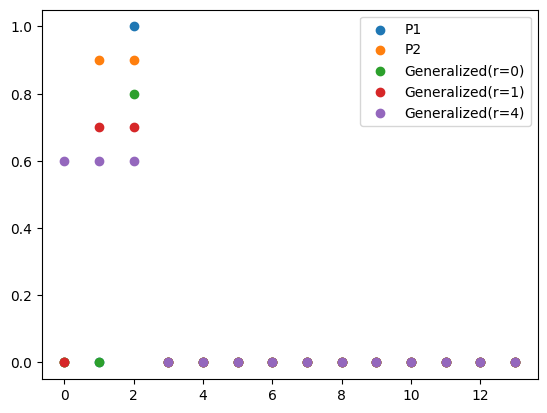

In [3]:
import matplotlib.pyplot as plt

n_max = 14
ns = np.arange(n_max)
plt.scatter(ns, poly_1(n_max) * 1, label="P1")
plt.scatter(ns, poly_2(n_max) * 0.9, label="P2")
for i, n_range in enumerate([0,1,4]):
    plt.scatter(ns, poly_generalized(n_max,  n_range) * (0.8 - i*0.1), label=f"Generalized(r={n_range})")
plt.legend()
plt.show()

In [11]:
def create_plt_x(f, res, title=None, only_on_target=False):
    sol_phis = res.phases
    x_samples = res.target.xs
    y_full = res.target.ys
    
    ax = f.gca()
    xs = np.array(sorted(x_samples)) if only_on_target else np.linspace(-1, 1, 30*len(x_samples))
    poly = qsp.evaluate_poly(sol_phis, xs)
    
    ax.plot(xs, poly.real, label="Re[P(x)]")
    ax.plot(xs, poly.imag, label="Im[P(x)]")
    ax.scatter(x_samples, y_full.real, label="Re[y_target]")
    ax.scatter(x_samples, y_full.imag, label="Im[y_target]", marker="x")
    if title:
        f.title(title)
    ax.legend()
    return f

def create_plt_k(f, res, title=None, only_on_target=False):
    sol_phis = res.phases
    y_full = res.target.ys
    ax = f.gca()
    N_half = len(y_full) // 2
    if only_on_target:
        ks = np.arange(0, N_half)
        thetas = np.array([qsp.theta_m_continuous(k, N_half) for k in ks])
        poly = qsp.evaluate_poly(sol_phis, np.cos(thetas))
        ax.plot(ks, poly.real, label="Re[P(cos(θ_k))]", c="lightgreen", ls="--", marker="D", ms=4, zorder=30)
        ax.plot(ks, poly.imag, label="Im[P(cos(θ_k))]", c="red", ls="--", marker="D", ms=4, zorder=30)
    else:
        ks = np.linspace(0, N_half-1, 30*N_half)
        thetas = np.array([qsp.theta_m_continuous(k, N_half) for k in ks])
        poly = qsp.evaluate_poly(sol_phis, np.cos(thetas))
        ax.plot(ks, poly.real, label="Re[P(cos(θ_k))]", c="lightgreen", ls="--", zorder=30)
        ax.plot(ks, poly.imag, label="Im[P(cos(θ_k))]", c="red", ls="--", zorder=30)

        # markers
        ks_m = np.arange(0,N_half)
        thetas_m = np.array([qsp.theta_m(k, N_half) for k in ks_m])
        poly_m = qsp.evaluate_poly(sol_phis, np.cos(thetas_m))
        ax.scatter(ks_m, poly_m.real, c="lightgreen", marker="D", s=16, zorder=30)
        ax.scatter(ks_m, poly_m.imag, c="red", marker="D", s=16, zorder=30)

    
    ax.set_xlabel("k")
    if title:
        f.title(title)
    ax.scatter(np.arange(0, N_half), y_full.real[N_half:], label="Re[y_target]", c="blue", zorder=15)
    ax.scatter(np.arange(0, N_half), y_full.imag[N_half:], label="Im[y_target]", marker="x", c="orange", zorder=15)
    ax.legend()
    return f


def pp_sq_err(res, print_all=False):
    phis = res.phases
    x_samples = res.target.xs
    y_full = res.target.ys
    p_at_samples = qsp.evaluate_poly(phis, x_samples)
    ppe = []
    for i in np.argsort(x_samples):
        err2 = (p_at_samples[i].real - y_full[i].real)**2 + p_at_samples[i].imag**2
        if print_all:
            print(f"  x={x_samples[i]:+.3f}  target={y_full[i].real:.0f}  P_re={p_at_samples[i].real:+.4f}  err²={err2:.4f}")
        ppe.append(err2)
        
    return np.sqrt(np.max(ppe))

def full_eval(res, title=None, only_on_target = False):
    print(f"Max. square pointwise error: {pp_sq_err(res)}")
    create_plt_x(plt, res, title, only_on_target).show()
    create_plt_k(plt, res, title, only_on_target).show()


In [7]:
ns_sweep = [2,3,4,5,6,7,8,9,10,20,30,40,50,100,200,300]
n_r = [0, 1]
deg = lambda n: int(n * (6 if n < 10 else 4.5))
results = []

for n_max in ns_sweep:
    for r in n_r:
        target_ys = poly_generalized(n_max, r)
            
        result = qsp.solve_poly(
            target_ys, 
            mode=f"s,{deg(n_max)}", 
            # Solver cannt do mirrored solution for all 0 ?? cannot get it to 
            # close for some reason
            phase_map="mirror" if n_max >= 7 else "none", 
            init="0" if n_max >= 7 else "0.4", 
            # This will try to find the lowest degree necessary. 
            # It performs a binary search starting with the given max degree. 
            # This means multiple solves which makes it very slow for large n_max. To get faster results, 
            # Dont rescale and assume something like d = \alpha * n_max where \alpha = 4.5 if n_max > 10 else 6 
            #rescale_to_err=1e-8, 
            solver="lm" if n_max <= 20 else "bfgs" 
        )
        print(f"[n_max={n_max}, r={r}] {result.termination} with final err {result.cost} in {result.elapsed_ms} ms")
        results.append(((n_max, r), result))

[n_max=2, r=0] converged with final err 8.335424799307959e-31 in 2.8694469999999996 ms
[n_max=2, r=1] converged with final err 8.335424799307959e-31 in 1.810466 ms
[n_max=3, r=0] converged with final err 1.84473273793187e-29 in 2.673713 ms
[n_max=3, r=1] converged with final err 1.84473273793187e-29 in 2.539032 ms
[n_max=4, r=0] converged with final err 2.78682062952833e-30 in 4.18667 ms
[n_max=4, r=1] converged with final err 2.78682062952833e-30 in 3.932626 ms
[n_max=5, r=0] converged with final err 5.145742958837567e-29 in 5.886355 ms
[n_max=5, r=1] converged with final err 5.145742958837567e-29 in 4.49165 ms
[n_max=6, r=0] converged with final err 6.357737895077743e-29 in 9.052467 ms
[n_max=6, r=1] converged with final err 6.357737895077743e-29 in 8.532602 ms
[n_max=7, r=0] converged with final err 1.3934416111257614e-29 in 13.708862 ms
[n_max=7, r=1] converged with final err 1.3934416111257614e-29 in 14.333561999999999 ms
[n_max=8, r=0] converged with final err 1.4625349497337611e

Max. square pointwise error: 4.8099091971866134e-08


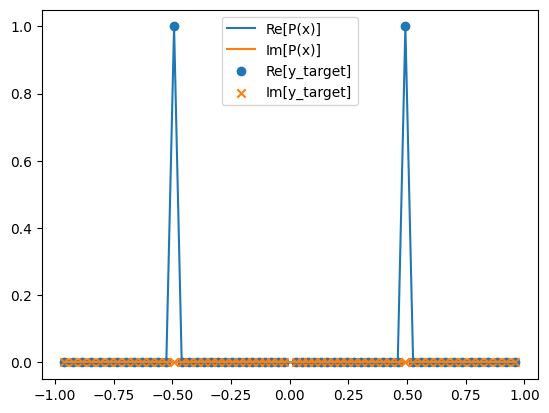

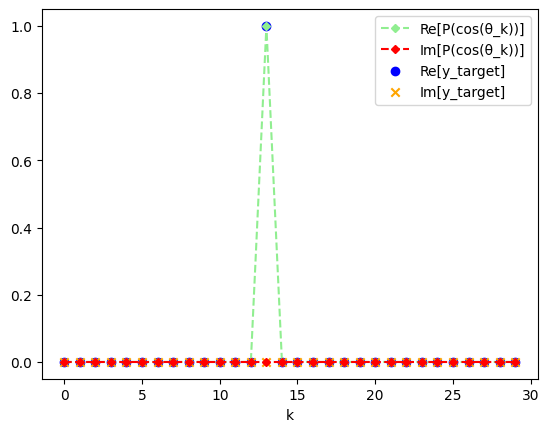

Max. square pointwise error: 5.9808988886603765e-06


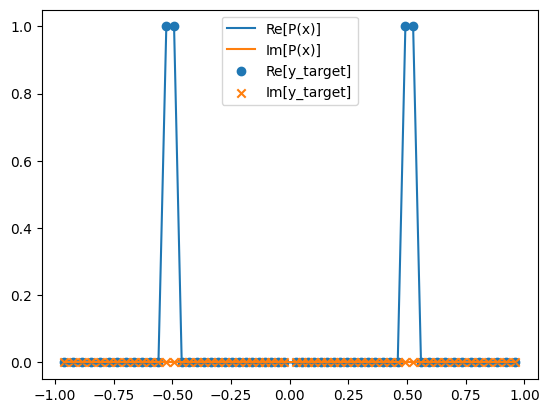

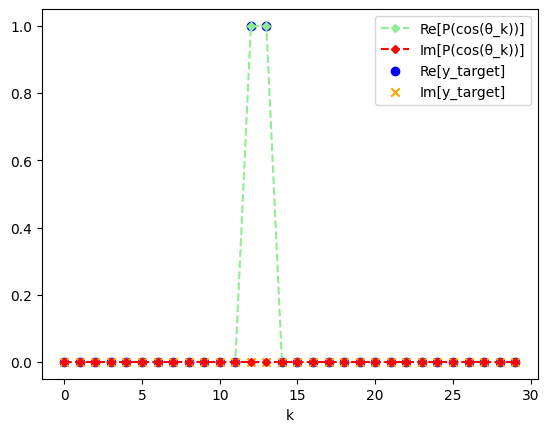

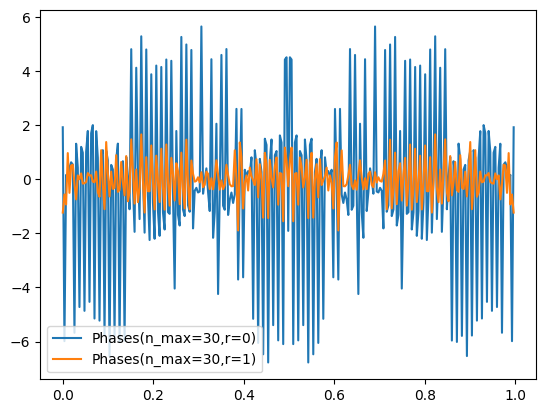

In [8]:
def de_mirror(phis):
    phis[0] -= np.pi/2
    return phis

def plot_phases(results):
    for _, res in results:
        full_eval(res, only_on_target=True)

    for (n_max, r), res in results:
        phis = de_mirror(res.phases)
        plt.plot(np.arange(len(phis)) / len(phis), phis, label=f"Phases(n_max={n_max},r={r})")
    plt.legend()
    plt.show()
    

plot_phases(results[20:22])

In [ ]:
import json
with open('mm_data.dat', 'w') as f:
    json.dump([ { "n_max": n_max, "r": r, "phis": list(res.phases), "cost": res.cost } for (n_max, r), res in results], f)